In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

# Overview of Data

### Load Data

In [3]:
df_complete = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Completed operations.csv",
    sep=";"
)
df_cancelled = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv",
    sep=";"
)

/var/folders/hs/9s0b5rgj539chsrz2hkbmzrr0000gn/T/ipykernel_84718/3917172957.py:1: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv(


In [4]:
df_complete.describe()

,Case-ID Anonymous,Patient Alder,Operationsgang ID,Forsinkelse (minutter),Overskredet (minutter),Staff.Anæstesiolog,Staff.Anæstesisygeplejerske,Staff.Gulvassistent,Staff.Operationssygeplejerske,Staff.Preprocedure Nurse,...,Ressource.Olympus Exera II (anæstesisøjle),Ressource.Sonostar,Ressource.COP3589 A O bøjejern rekonstruktionsskinner,Ressource.BMAC-centrifuge,Ressource.Benchbord,Ressource.Diodelaser næse,Ressource.Øre optik 30°,Ressource.Endoskop,Ressource.Flexcystoskop,Ressource.Kasette
count,133158.000000,133158.000000,133158.000000,132491.000000,132537.000000,74832.0,79227.0,113625.0,119226.0,80560.0,...,2.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,2.0,0.0
mean,60156.037437,53.788244,40663.550909,20.511642,25.346198,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
std,34927.061620,24.889920,52262.972747,50.977296,68.894706,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN
min,1.000000,0.000000,618.000000,-3045.000000,-3003.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
25%,29928.250000,34.000000,622.000000,0.000000,-10.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
50%,60097.500000,61.000000,625.000000,14.000000,23.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
75%,90338.750000,74.000000,107621.000000,40.000000,57.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
max,120868.000000,107.000000,133218.000000,1585.000000,1560.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


### Exploring Delays

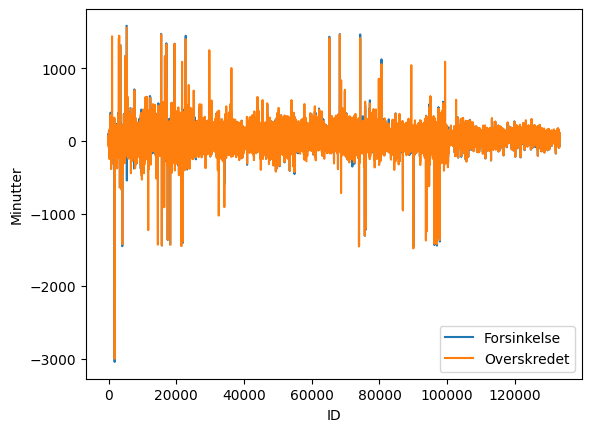

In [5]:
forsinkelse_col = df_complete['Forsinkelse (minutter)']
overskredet_col = df_complete['Overskredet (minutter)']
plt.plot(forsinkelse_col, label='Forsinkelse')
plt.plot(overskredet_col, label='Overskredet')
plt.legend()
plt.ylabel('Minutter')
plt.xlabel('ID')
plt.show()

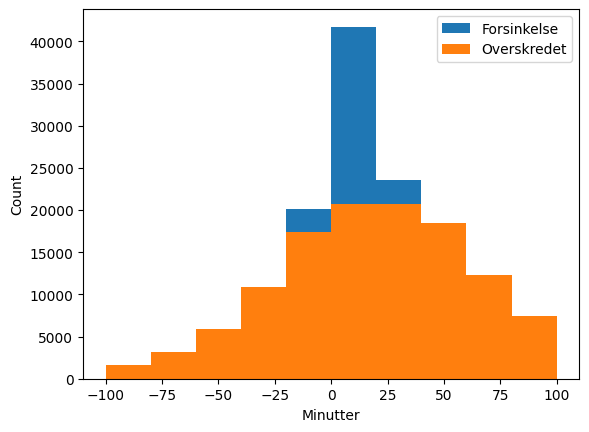

In [6]:
forsinkelse_col_mid = df_complete[df_complete['Forsinkelse (minutter)'].between(-100,100)]['Forsinkelse (minutter)']
overskredet_col_mid = df_complete[df_complete['Overskredet (minutter)'].between(-100,100)]['Overskredet (minutter)']
plt.hist(forsinkelse_col_mid, label='Forsinkelse')
plt.hist(overskredet_col_mid, label='Overskredet')
plt.legend()
plt.ylabel('Count')
plt.xlabel('Minutter')
plt.show()

#### Compute confidence intervals for "Forsinkelse" and "Overskredet" observations

In [7]:
# Change to 2.576 for 99% CI
mean_forsinkelse = forsinkelse_col.mean()
se_forsinkelse = forsinkelse_col.std(ddof=1)
ci_lower_forsinkelse = mean_forsinkelse - 1.96 * se_forsinkelse 
ci_upper_forsinkelse = mean_forsinkelse + 1.96 * se_forsinkelse

mean_overskredet = overskredet_col.mean()
se_overskredet = overskredet_col.std(ddof=1)
ci_lower_overskredet = mean_overskredet - 1.96 * se_overskredet
ci_upper_overskredet = mean_overskredet + 1.96 * se_overskredet

print(f"{'Forsinkelse 95% CI:':20}{np.round((ci_lower_forsinkelse,ci_upper_forsinkelse), 3)}")
print(f"{'Overskredet 95% CI:':20}{np.round((ci_lower_overskredet,ci_upper_overskredet), 3)}")

Forsinkelse 95% CI: [-79.404 120.427]
Overskredet 95% CI: [-109.687  160.38 ]


In [8]:
frac_delay = len(df_complete[df_complete['Forsinkelse (minutter)'] > 0]) / len(df_complete)
frac_delay_reason = len(df_complete[(df_complete['Forsinkelse (minutter)'] > 0) & 
                                    (df_complete['Forsinkelsesårsag'].notna())]) / len(df_complete['Forsinkelse (minutter)'] > 0)

# Reserve 50 characters for the text so numbers align
print(f"{'Fraction of operations delayed:':50}{frac_delay}")
print(f"{'Fraction of delayed operations with reason:':50}{frac_delay_reason}")

Fraction of operations delayed:                   0.726685591552892
Fraction of delayed operations with reason:       0.024624881719461093


# Data Preparation

### Convert and Create New Variables

In [9]:
# Convert to date time
daytime_vars = ['Dato', 'Pt ankommet til hospitalet', 'Planlagt stue klargøring start', 
            'Stue klargøring start', 'Stue klargjort', 'Patient på stuen', 
            'Patient på stuen (Planlagt)', 'Anæstesistart', 'Anæstesi melder klar',
            'Procedure start', 'Procedure slut', 'Patient klar til afgang', 
            'Patient forlader stuen (Planlagt)', 'Patient forlader stuen', 'Stue rengjort (Planlagt)',
            'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop', 
            'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling']
for var in daytime_vars:
    df_complete[var] = pd.to_datetime(df_complete[var], format='%Y-%m-%d %H:%M:%S,%f')

# Add staff amount
staff_columns = [col for col in df_complete.columns if col.startswith("Staff")]
df_complete['Staff amount'] = df_complete[staff_columns].sum(axis=1)

# Add ressource amount
ressource_columns = [col for col in df_complete.columns if col.startswith("Ressource")]
df_complete['Ressource amount'] = df_complete[ressource_columns].sum(axis=1)

# Change NaNs in Staff and Ressource columns to zeros (if they are included as features)
#df_cluster_clean[staff_columns] = df_cluster_clean[staff_columns].fillna(0)
#df_cluster_clean[ressource_columns] = df_cluster_clean[ressource_columns].fillna(0)

# One hot encoding of "Speciale" and "Akut case" and "Operationsgang ID"
df_complete = pd.get_dummies(df_complete, columns=['Speciale'], dtype=int)
df_complete['Akut case (J/N)'] = df_complete['Akut case (J/N)'].replace({'Ja': 1, 'Nej': 0})
df_complete = pd.get_dummies(df_complete, columns=['Operationsgang ID'], dtype=int)

# Add month variable, where sine and cosine are used to ensure similar features for close months
months = df_complete['Dato'].dt.month
df_complete['Måned_sin'] = np.sin(2 * np.pi * months/12)
df_complete['Måned_cos'] = np.cos(2 * np.pi * months/12)

### Feature selection

In [10]:
daytime_cols_to_drop = ['Dato', 'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
                        'Stue klargøring start', 'Stue klargjort', 'Patient på stuen (Planlagt)', 
                        'Patient på stuen', 'Anæstesistart', 'Anæstesi melder klar', 'Procedure start', 
                        'Procedure slut', 'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
                        'Patient forlader stuen', 'Stue rengjort (Planlagt)', 'Stue rengøring start', 
                        'Stue rengjort', 'I opvågning', 'Anæstesistop','Klar til udskrivelse efter opvågning', 
                        'Patient forlader afdeling','Forsinkelsesårsag']
staff_cols_to_drop = [col for col in df_complete.columns if col.startswith("Staff.")]
ressource_cols_to_drop = [col for col in df_complete.columns if col.startswith("Ressource.")]
other_cols_to_drop = ['Case-ID Anonymous', 'Stue', 'Procedure - Tekst & ID', 
                      'Aktionsdiagnose - Kode & tekst', 'Aktionsdiagnose - Gruppe']
cols_to_drop = daytime_cols_to_drop + staff_cols_to_drop + ressource_cols_to_drop + other_cols_to_drop
df_cluster = df_complete.drop(columns=cols_to_drop)
print(f"Number of samples before exclusion: {len(df_cluster)}")

Number of samples before exclusion: 133158


### Exclude Outliers (Based on "Forsinkelse" and "Overskredet")

In [11]:
df_cluster = df_cluster[df_cluster['Forsinkelse (minutter)'].between(ci_lower_forsinkelse, ci_upper_forsinkelse)]
df_cluster = df_cluster[df_cluster['Overskredet (minutter)'].between(ci_lower_overskredet, ci_upper_overskredet)]
print(f"Number of samples after outlier exclusion: {len(df_cluster)}")

Number of samples after outlier exclusion: 124570


### Exclude cases with missing data

In [12]:
df_cluster_clean = df_cluster

# Drop rows with NaN
df_cluster_clean = df_cluster_clean.dropna()
print(f"Number of samples after NaN/NaT exclusion: {len(df_cluster_clean)}")

Number of samples after NaN/NaT exclusion: 124570


In [13]:
df_cluster_clean

,Patient Alder,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Staff amount,Ressource amount,Speciale_Alloplastik,Speciale_Anæstesiologi,Speciale_Brystkirurgi,Speciale_Børnekirurgi,...,Operationsgang ID_618,Operationsgang ID_620,Operationsgang ID_622,Operationsgang ID_624,Operationsgang ID_625,Operationsgang ID_107621,Operationsgang ID_107622,Operationsgang ID_133218,Måned_sin,Måned_cos
0,29,0,95.0,36.0,5.0,1.0,0,0,0,0,...,0,0,0,0,0,1,0,0,1.000000e+00,6.123234e-17
1,60,0,8.0,30.0,4.0,1.0,0,0,0,0,...,0,0,0,0,0,1,0,0,5.000000e-01,8.660254e-01
2,60,0,8.0,30.0,4.0,1.0,0,0,0,0,...,0,0,0,0,0,1,0,0,5.000000e-01,8.660254e-01
3,12,0,16.0,-3.0,4.0,1.0,0,0,0,0,...,0,0,0,0,0,1,0,0,5.000000e-01,8.660254e-01
4,57,0,16.0,1.0,3.0,1.0,0,0,0,0,...,0,0,0,0,0,1,0,0,-8.660254e-01,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133153,59,0,47.0,51.0,4.0,0.0,0,0,0,0,...,0,0,0,0,1,0,0,0,-2.449294e-16,1.000000e+00
133154,58,0,35.0,40.0,4.0,0.0,0,0,0,0,...,0,0,0,0,1,0,0,0,-2.449294e-16,1.000000e+00
133155,70,0,52.0,52.0,4.0,0.0,0,0,0,0,...,0,0,0,0,1,0,0,0,-2.449294e-16,1.000000e+00
133156,87,0,42.0,50.0,4.0,0.0,0,0,0,0,...,0,0,0,0,1,0,0,0,-2.449294e-16,1.000000e+00


### Scale Data

In [14]:
# Check that all columns are numerical data
print(f"All columns are numerical: {len(df_cluster_clean.select_dtypes(include='number').columns) == 48}")
# Identify one hot encoding columns
dummy_cols = [c for c in df_cluster_clean.columns 
              if df_cluster_clean[c].dropna().isin([0,1]).all()]
# Identify continuous columns
continuous_cols = [c for c in df_cluster_clean.columns if c not in dummy_cols]

All columns are numerical: True


In [15]:
# Scale all columns that are not one hot encodings
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols),
        ("cat", "passthrough", dummy_cols)
    ]
)
X_scaled = preprocessor.fit_transform(df_cluster_clean)

### Do K-Means Clustering 

In [27]:
# Perform clustering
k = 3

#kmeans = KMeans(n_clusters=k,random_state=2026,n_init=20)

kmeans = KMeans(n_clusters=k, random_state=2026)
kmeans.fit(X_scaled)

# Assign cluster labels to final DataFrame
df_final = df_cluster_clean.copy()
df_final['cluster'] = kmeans.labels_

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [20]:
df_final['cluster'] = kmeans.predict(X_scaled)

Inspect results

In [26]:
# Count of rows per cluster
print(df_final['cluster'].value_counts())

cluster
1    49310
2    42053
0    33207
Name: count, dtype: int64


In [22]:
# Compare mean values per cluster
cluster_summary = df_final.groupby('cluster').mean()
cluster_summary

,Patient Alder,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Staff amount,Ressource amount,Speciale_Alloplastik,Speciale_Anæstesiologi,Speciale_Brystkirurgi,Speciale_Børnekirurgi,...,Operationsgang ID_618,Operationsgang ID_620,Operationsgang ID_622,Operationsgang ID_624,Operationsgang ID_625,Operationsgang ID_107621,Operationsgang ID_107622,Operationsgang ID_133218,Måned_sin,Måned_cos
cluster,,,,,,,,,,,,,,,,,,,,,
0,49.685247,0.126178,14.950613,28.454543,7.630650,3.040985,0.006806,0.000060,0.000120,0.006414,...,0.127052,0.026290,0.030114,0.135965,0.012196,0.591472,0.076911,0.000000,0.004734,0.049884
1,43.811722,0.264024,-2.664348,-8.592578,5.575076,0.776780,0.002028,0.001927,0.000061,0.069296,...,0.130765,0.223626,0.149483,0.003731,0.118455,0.302636,0.044413,0.026891,0.023393,-0.005996
2,68.582931,0.144746,48.421302,55.646732,4.379830,0.267496,0.000761,0.000642,0.000000,0.005921,...,0.069912,0.026467,0.021568,0.001546,0.736689,0.085559,0.043635,0.014624,0.013671,0.039611


In [18]:
cluster_summary['Speciale_Øjenkirurgi']

cluster
0    0.012708
1    0.130217
2    0.779849
Name: Speciale_Øjenkirurgi, dtype: float64

## PCA

### 2D PCA and Plotting

Explained variance ratios for PCA components: [0.25140562 0.15158415]


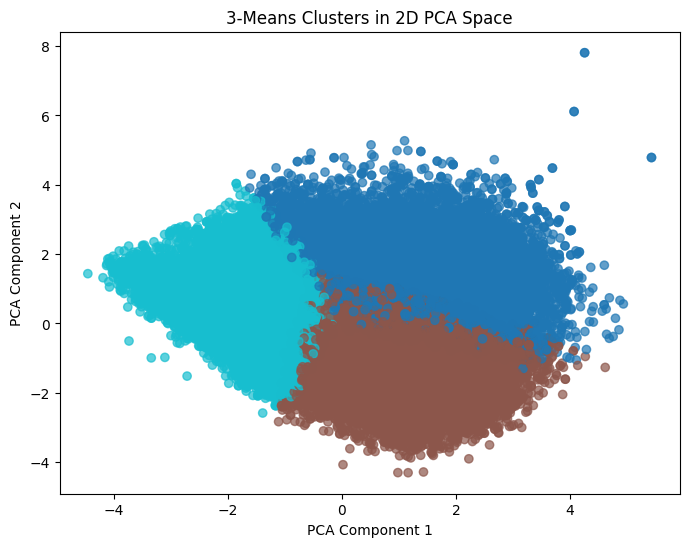

In [20]:
# Do PCA
pca2D = PCA(n_components=2)
X_pca2D = pca2D.fit_transform(X_scaled)
print(f"Explained variance ratios for PCA components: {pca2D.explained_variance_ratio_}")

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(X_pca2D[:,0], X_pca2D[:,1], c=df_final['cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'{k}-Means Clusters in 2D PCA Space')
plt.show()

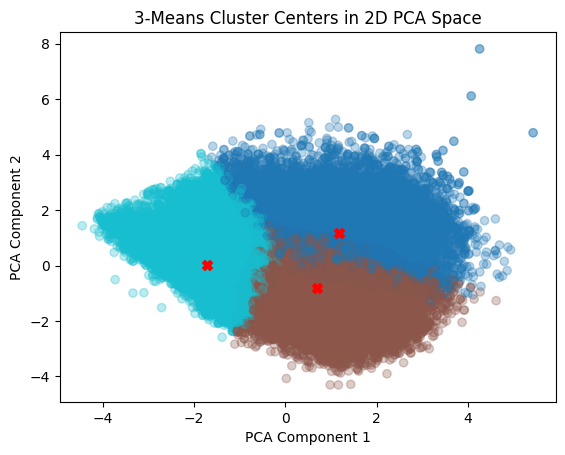

In [21]:
centers_pca2D = pca2D.transform(kmeans.cluster_centers_)
plt.scatter(X_pca2D[:,0], X_pca2D[:,1], c=kmeans.labels_, alpha=0.3, cmap='tab10')
plt.scatter(centers_pca2D[:,0], centers_pca2D[:,1], s=50, c='red', marker='X')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'{k}-Means Cluster Centers in 2D PCA Space')
plt.show()

### 3D PCA and Plotting

In [23]:
#pca3D = PCA(n_components=3)
#X_pca3D = pca3D.fit_transform(X_scaled)
#print(pca3D.explained_variance_ratio_)

#%matplotlib qt

#fig = plt.figure(figsize=(8,6))
#ax = fig.add_subplot(111, projection='3d')
#scatter = ax.scatter(X_pca3D[:,0], X_pca3D[:,1], X_pca3D[:,2], c=df_final['cluster'], cmap='tab10', alpha=0.7)

#ax.set_xlabel('PCA Component 1')
#ax.set_ylabel('PCA Component 2')
#ax.set_zlabel('PCA Component 3')
#plt.title('5-Means Clusters in 3D PCA Space')
#plt.show()

In [24]:
#centers_pca3D = pca3D.transform(kmeans.cluster_centers_)

# create 3D figure
#fig = plt.figure(figsize=(8,8))
#ax = fig.add_subplot(111, projection='3d')
# scatter points
#ax.scatter(
#    X_pca3D[:,0], X_pca3D[:,1], X_pca3D[:,2],
#    c=kmeans.labels_,
#    alpha=0.3,
#    cmap='tab10'
#)
# scatter cluster centers
#ax.scatter(
#    centers_pca3D[:,0], centers_pca3D[:,1], centers_pca3D[:,2],
#    s=100,
#    c='red',
#    marker='X'
#)
#ax.set_xlabel('PCA Component 1')
#ax.set_ylabel('PCA Component 2')
#ax.set_zlabel('PCA Component 3')
#plt.title('5-Means Cluster Centers in 3D PCA Space')
#plt.show()

### 10D PCA

[0.25140562 0.15158415 0.11773985 0.10985791 0.10855093 0.05709453
 0.03642368 0.0314032  0.02508231 0.01550867]


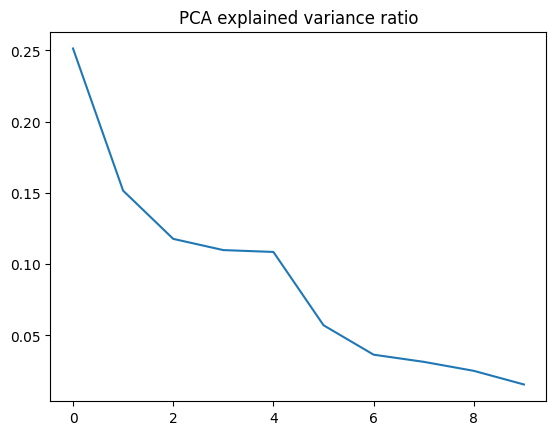

In [22]:
pca10D = PCA(n_components=10)
pca10D.fit(X_scaled)
print(pca10D.explained_variance_ratio_)

%matplotlib inline
plt.plot(np.arange(len(pca10D.explained_variance_ratio_)),pca10D.explained_variance_ratio_)
plt.title('PCA explained variance ratio')
plt.show()

# Use Random Forrest to Predict Importance of Features

In [23]:
X_scaled = preprocessor.fit_transform(df_cluster_clean)

# Fit random forest
rf = RandomForestClassifier(random_state=2026)
rf.fit(X_scaled, kmeans.labels_)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=df_cluster_clean.columns).sort_values(ascending=False)
print(importances)

Staff amount                               1.872178e-01
Akut case (J/N)                            1.717760e-01
Forsinkelse (minutter)                     1.669193e-01
Overskredet (minutter)                     1.309641e-01
Operationsgang ID_618                      7.700912e-02
Patient Alder                              7.466474e-02
Operationsgang ID_107622                   5.145555e-02
Operationsgang ID_624                      1.822999e-02
Operationsgang ID_133218                   1.596793e-02
Operationsgang ID_620                      1.448263e-02
Speciale_Alloplastik                       1.234764e-02
Ressource amount                           1.217984e-02
Speciale_Thoraxkirurgi                     1.052299e-02
Operationsgang ID_625                      8.089800e-03
Operationsgang ID_107621                   7.404296e-03
Speciale_Anæstesiologi                     6.759410e-03
Speciale_Rygkirurgi                        3.718076e-03
Speciale_Tumorortopædi                     3.048

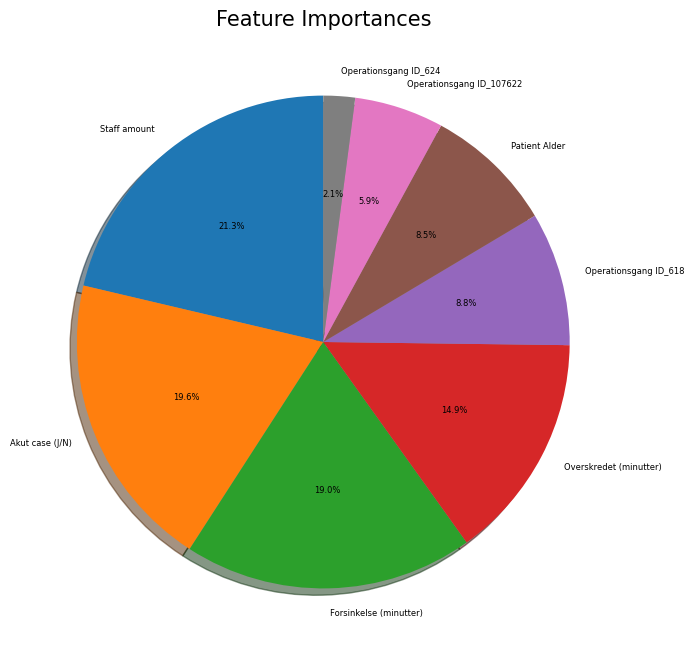

In [24]:
# Use the top features
top_importances = importances.head(8)

plt.figure(figsize=(8,8))
plt.pie(top_importances.values, labels=top_importances.index, 
        autopct='%1.1f%%', startangle=90, shadow=True, textprops={'fontsize':6})
plt.title("Feature Importances", fontsize=15)
plt.show()

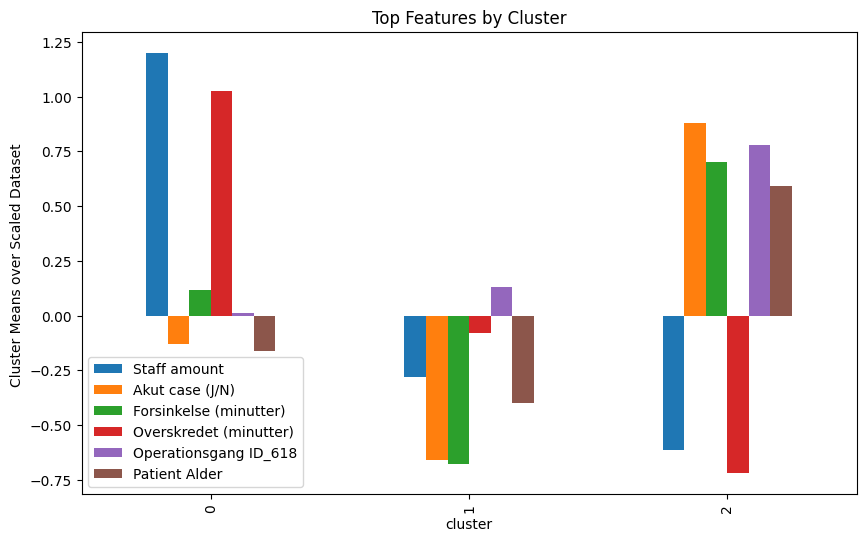

In [30]:
df_scaled = pd.DataFrame(X_scaled, columns=df_cluster_clean.columns)
df_scaled['cluster'] = kmeans.labels_

top_features = importances.head(6).index
df_scaled.groupby('cluster')[top_features].mean().plot(kind='bar', figsize=(10,6))

plt.ylabel("Cluster Means over Scaled Dataset ")
plt.title("Top Features by Cluster")
plt.show()

In [31]:
df_final.groupby('cluster')[top_features].mean()

,Staff amount,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Operationsgang ID_618,Patient Alder
cluster,,,,,,
0,7.630650,0.126178,14.950613,28.454543,0.127052,49.685247
1,5.575076,0.264024,-2.664348,-8.592578,0.130765,43.811722
2,4.379830,0.144746,48.421302,55.646732,0.069912,68.582931


In [33]:
spec_cols = [col for col in cluster_summary.columns if col.startswith("Speciale_")]
print(np.array(cluster_summary[spec_cols][cluster_summary.index==0]).sum())
for cluster in range(len(cluster_summary)):
    print(cluster_summary[cluster_summary.index==cluster]['Speciale_Øjenkirurgi'])

1.0
cluster
0    0.012708
Name: Speciale_Øjenkirurgi, dtype: float64
cluster
1    0.130217
Name: Speciale_Øjenkirurgi, dtype: float64
cluster
2    0.779849
Name: Speciale_Øjenkirurgi, dtype: float64


In [34]:
n_øjenkirurgi = (df_final['Speciale_Øjenkirurgi'] == 1).sum()
print('Andel af operationer med speciale i øjenkirurgi, der er assigned til hver cluster:\n')
for c in range(len(cluster_summary)):
    n_cluster = len(df_final[ (df_final['Speciale_Øjenkirurgi'] == 1) & (df_final['cluster'] == c)])
    print(f"Cluster {c}: \
          {np.round(n_cluster / n_øjenkirurgi, 3)}")

Andel af operationer med speciale i øjenkirurgi, der er assigned til hver cluster:

Cluster 0:           0.011
Cluster 1:           0.162
Cluster 2:           0.827


In [36]:
operationsgang_cols = [col for col in df_complete.columns if col.startswith("Operationsgang")]
for gang in operationsgang_cols:
    print(cluster_summary[cluster_summary.index==2][gang])

cluster
2    0.069912
Name: Operationsgang ID_618, dtype: float64
cluster
2    0.026467
Name: Operationsgang ID_620, dtype: float64
cluster
2    0.021568
Name: Operationsgang ID_622, dtype: float64
cluster
2    0.001546
Name: Operationsgang ID_624, dtype: float64
cluster
2    0.736689
Name: Operationsgang ID_625, dtype: float64
cluster
2    0.085559
Name: Operationsgang ID_107621, dtype: float64
cluster
2    0.043635
Name: Operationsgang ID_107622, dtype: float64
cluster
2    0.014624
Name: Operationsgang ID_133218, dtype: float64
